In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic dataset directly
df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# Show first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [33]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

# Fill missing Age with median
df['Age'].fillna(df['Age'].median(), inplace=True)

# Fill missing Embarked with mode
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Drop Cabin column (too many missing)
df.drop('Cabin', axis=1, inplace=True)

print("\nAfter Cleaning:")
print(df.isnull().sum())

Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_3306/2374294185.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_3306/2374294185.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

/tmp/ipykernel_3306/1358841132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette=['red','green'], ax=axes[0,0])
/tmp/ipykernel_3306/1358841132.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0,0].set_xticklabels(['Not Survived', 'Survived'])


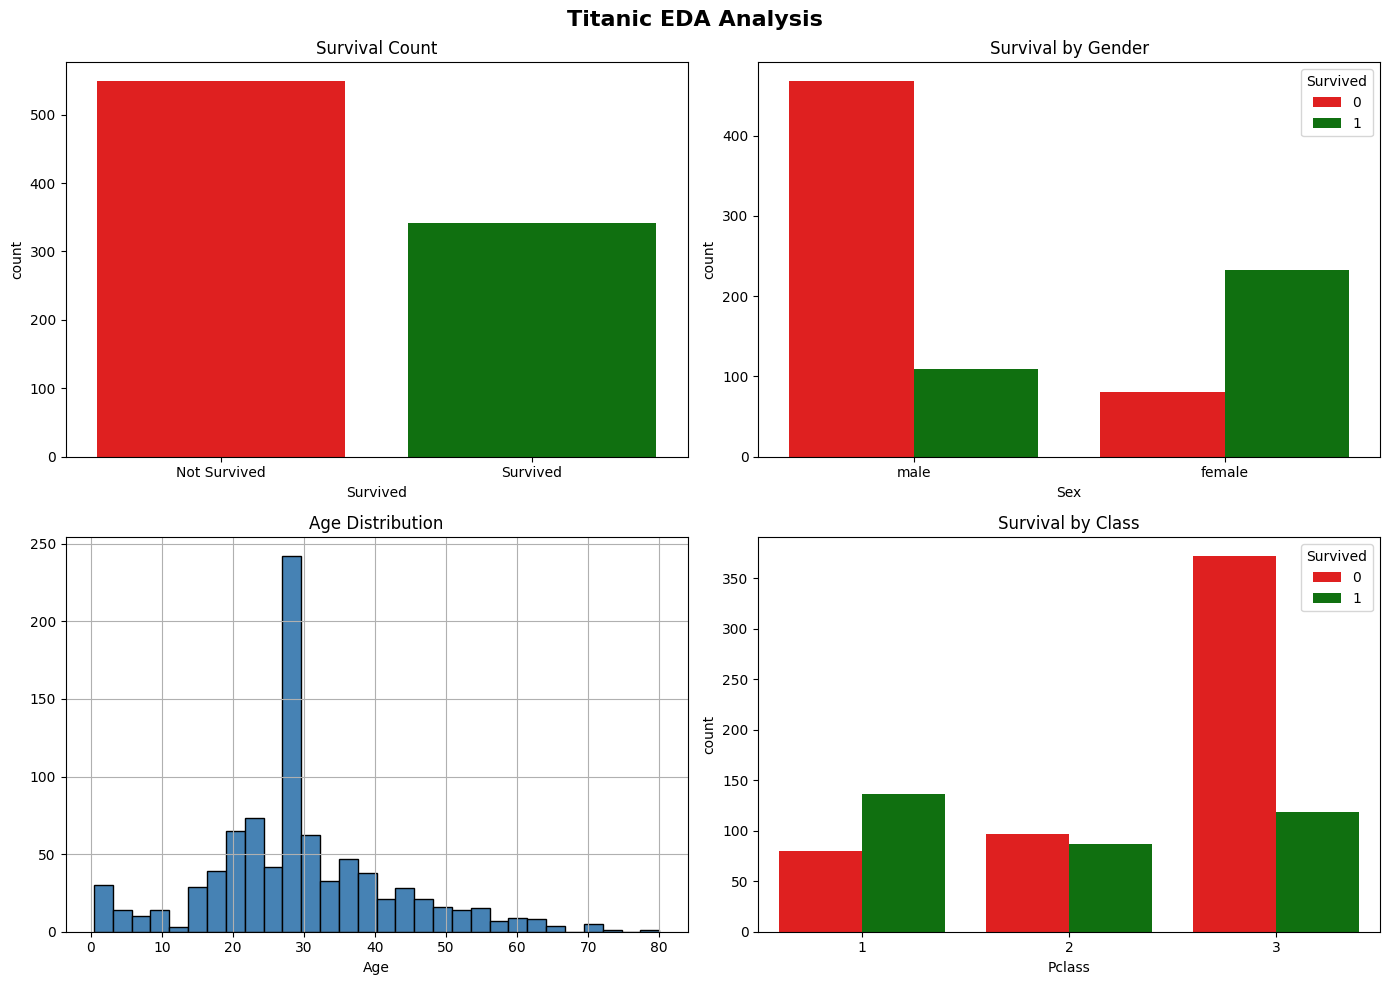

Saved!


In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic EDA Analysis', fontsize=16, fontweight='bold')

# Chart 1: Survival Count
sns.countplot(x='Survived', data=df, palette=['red','green'], ax=axes[0,0])
axes[0,0].set_title('Survival Count')
axes[0,0].set_xticklabels(['Not Survived', 'Survived'])

# Chart 2: Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df, palette=['red','green'], ax=axes[0,1])
axes[0,1].set_title('Survival by Gender')

# Chart 3: Age Distribution
df['Age'].hist(bins=30, ax=axes[1,0], color='steelblue', edgecolor='black')
axes[1,0].set_title('Age Distribution')
axes[1,0].set_xlabel('Age')

# Chart 4: Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df, palette=['red','green'], ax=axes[1,1])
axes[1,1].set_title('Survival by Class')

plt.tight_layout()
plt.savefig('SCT_DS_2.png', dpi=150)
plt.show()
print("Saved!")